In [1]:
# Cell 0 — Setup & Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot style
sns.set(style="whitegrid", palette="Set2")


In [3]:
# Cell 1 — Upload & Load the Palmer Penguins dataset (from local computer)
from google.colab import files
import pandas as pd

# Prompt upload dialog
uploaded = files.upload()

# Get the uploaded filename (first key)
filename = list(uploaded.keys())[0]

# Load CSV into DataFrame
df = pd.read_csv(filename)
print("✅ Dataset loaded with shape:", df.shape)
df.head()


Saving Palmer_Penguins_Dataset.csv to Palmer_Penguins_Dataset.csv
✅ Dataset loaded with shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
# Cell 2 — Basic data cleaning
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values (simplest approach for now)
df_clean = df.dropna().copy()

print("✅ Cleaned dataset shape:", df_clean.shape)
df_clean.dtypes


Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
✅ Cleaned dataset shape: (333, 8)


,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


In [5]:
# Cell 3 — Summary statistics and unique values
print("Summary statistics:")
display(df_clean.describe())

print("\nUnique values per categorical column:")
for col in df_clean.select_dtypes(include="object").columns:
    print(f"{col}: {df_clean[col].unique()}")


Summary statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000



Unique values per categorical column:
species: ['Adelie' 'Gentoo' 'Chinstrap']
island: ['Torgersen' 'Biscoe' 'Dream']
sex: ['male' 'female']


/tmp/ipython-input-858445985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="species", data=df_clean, palette="Set2")


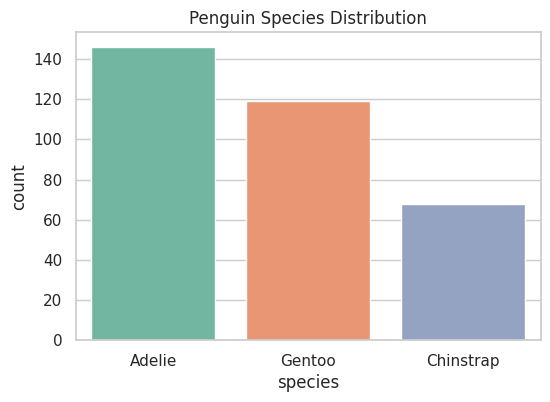

In [6]:
# Cell 4 — Species distribution
plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df_clean, palette="Set2")
plt.title("Penguin Species Distribution")
plt.show()


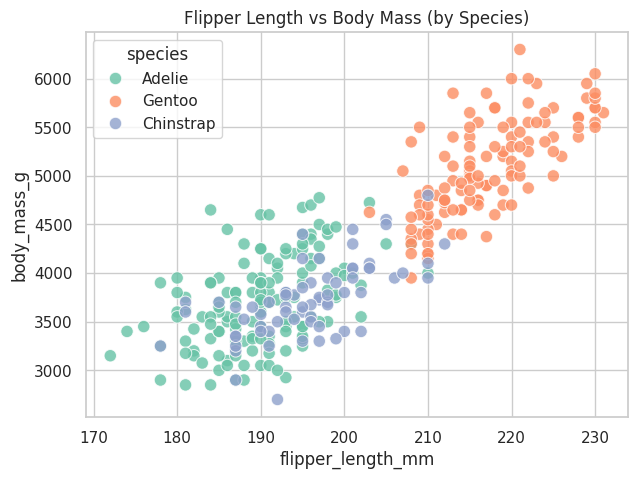

In [7]:
# Cell 5 — Scatter plot Flipper Length vs Body Mass
plt.figure(figsize=(7,5))
sns.scatterplot(x="flipper_length_mm", y="body_mass_g",
                hue="species", data=df_clean, s=80, alpha=0.8)
plt.title("Flipper Length vs Body Mass (by Species)")
plt.show()


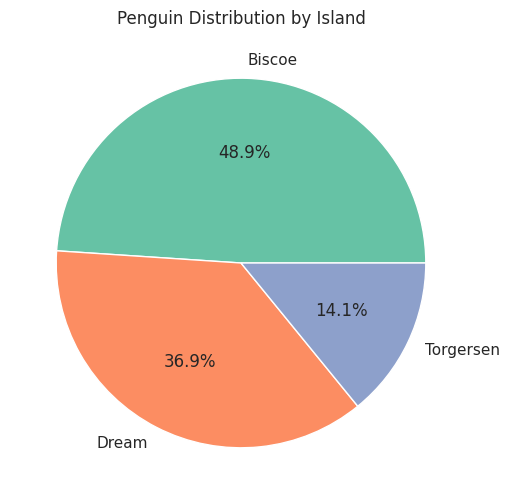

In [8]:
# Cell 6 — Island distribution
island_counts = df_clean["island"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(island_counts, labels=island_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title("Penguin Distribution by Island")
plt.show()


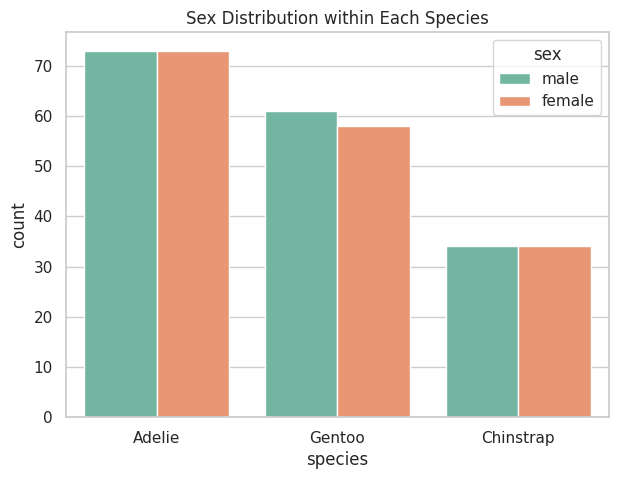

In [9]:
# Cell 7 — Grouped bar chart for Sex distribution within Species
plt.figure(figsize=(7,5))
sns.countplot(x="species", hue="sex", data=df_clean, palette="Set2")
plt.title("Sex Distribution within Each Species")
plt.show()


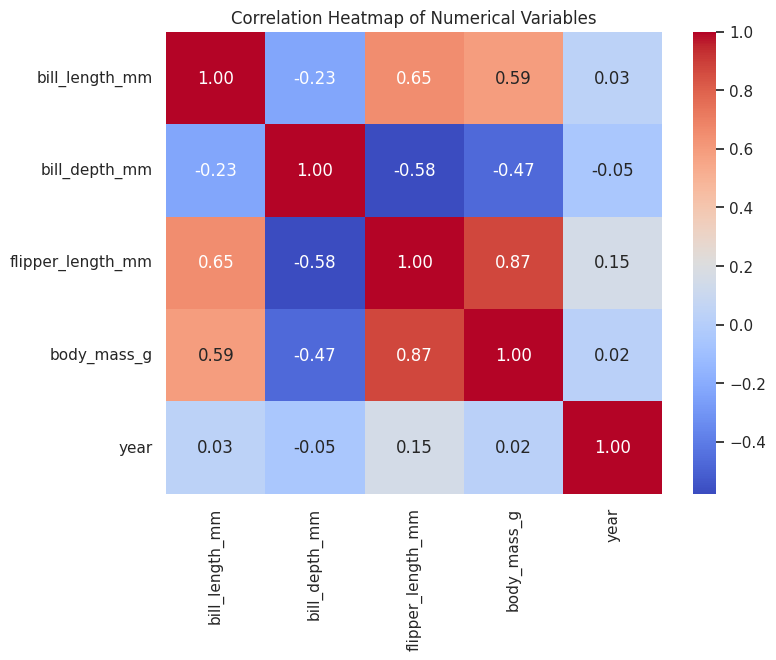

In [10]:
# Cell 8 — Heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


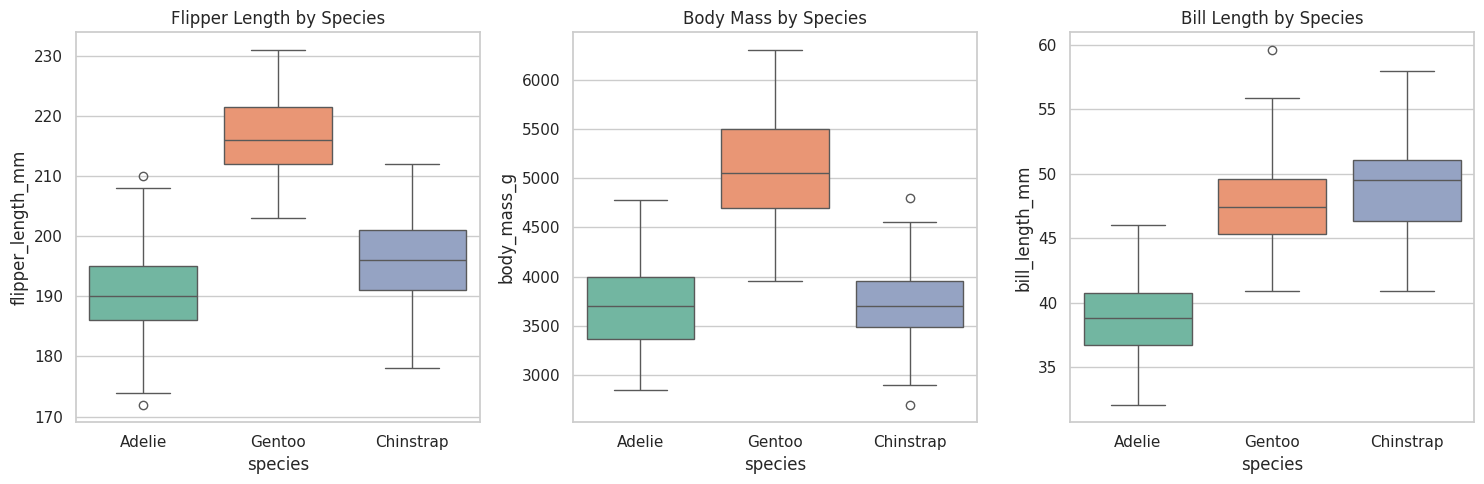

In [12]:
# Cell 9 — Boxplots segmented by Species (fixed for Seaborn ≥0.14)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x="species", y="flipper_length_mm", hue="species",
            data=df_clean, ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Flipper Length by Species")

sns.boxplot(x="species", y="body_mass_g", hue="species",
            data=df_clean, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Body Mass by Species")

sns.boxplot(x="species", y="bill_length_mm", hue="species",
            data=df_clean, ax=axes[2], palette="Set2", legend=False)
axes[2].set_title("Bill Length by Species")

plt.tight_layout()
plt.show()


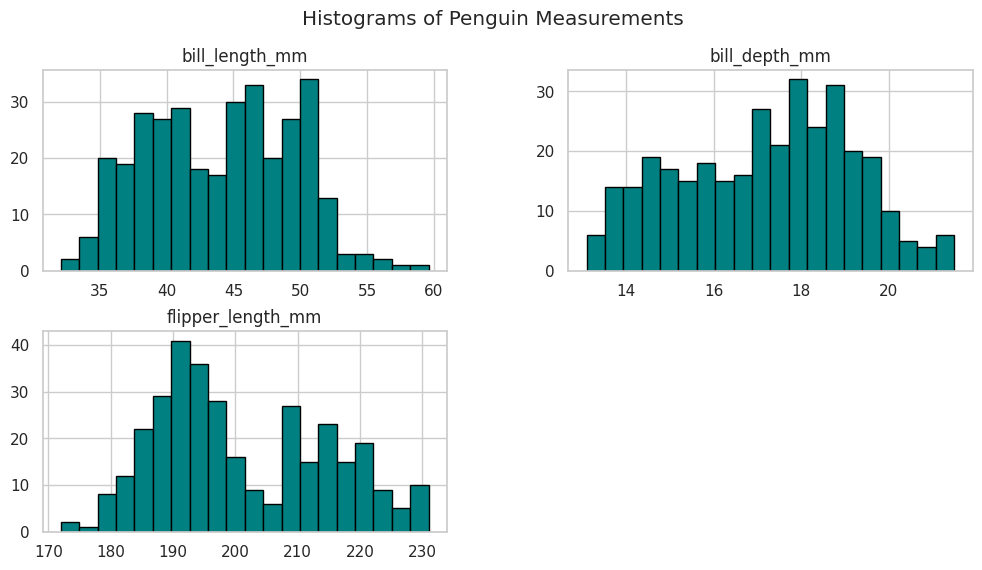

In [13]:
# Cell 10 — Histograms of key measurements
df_clean[["bill_length_mm","bill_depth_mm","flipper_length_mm"]].hist(
    bins=20, figsize=(12,6), color="teal", edgecolor="black")
plt.suptitle("Histograms of Penguin Measurements")
plt.show()


/tmp/ipython-input-3528916526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="species", y="flipper_length_mm", data=df_clean,


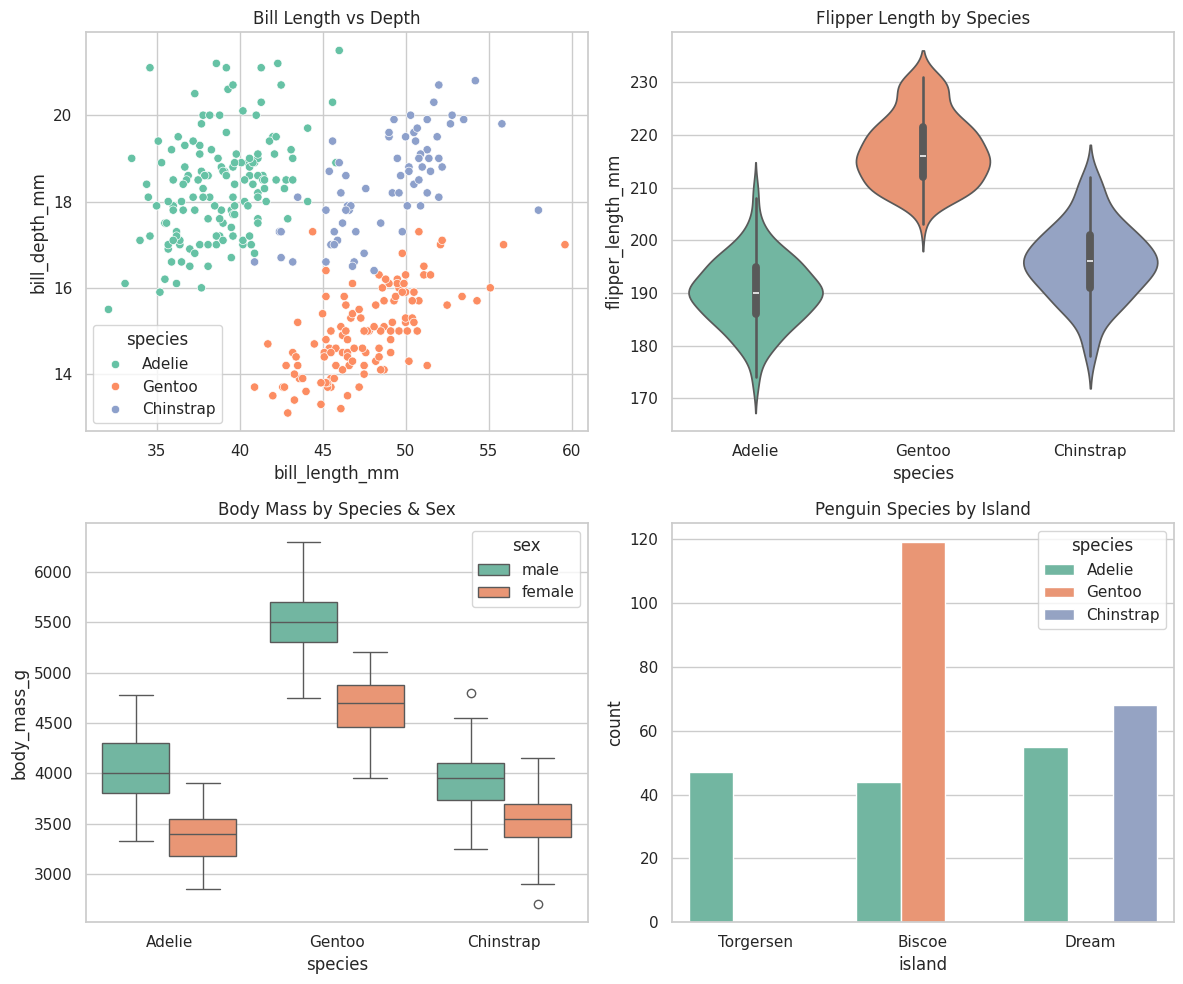

In [14]:
# Cell 11 — Multiple subplots to compare distributions
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.scatterplot(x="bill_length_mm", y="bill_depth_mm", hue="species",
                data=df_clean, ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Bill Length vs Depth")

sns.violinplot(x="species", y="flipper_length_mm", data=df_clean,
               ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Flipper Length by Species")

sns.boxplot(x="species", y="body_mass_g", hue="sex",
            data=df_clean, ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Body Mass by Species & Sex")

sns.countplot(x="island", hue="species", data=df_clean,
              ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Penguin Species by Island")

plt.tight_layout()
plt.show()


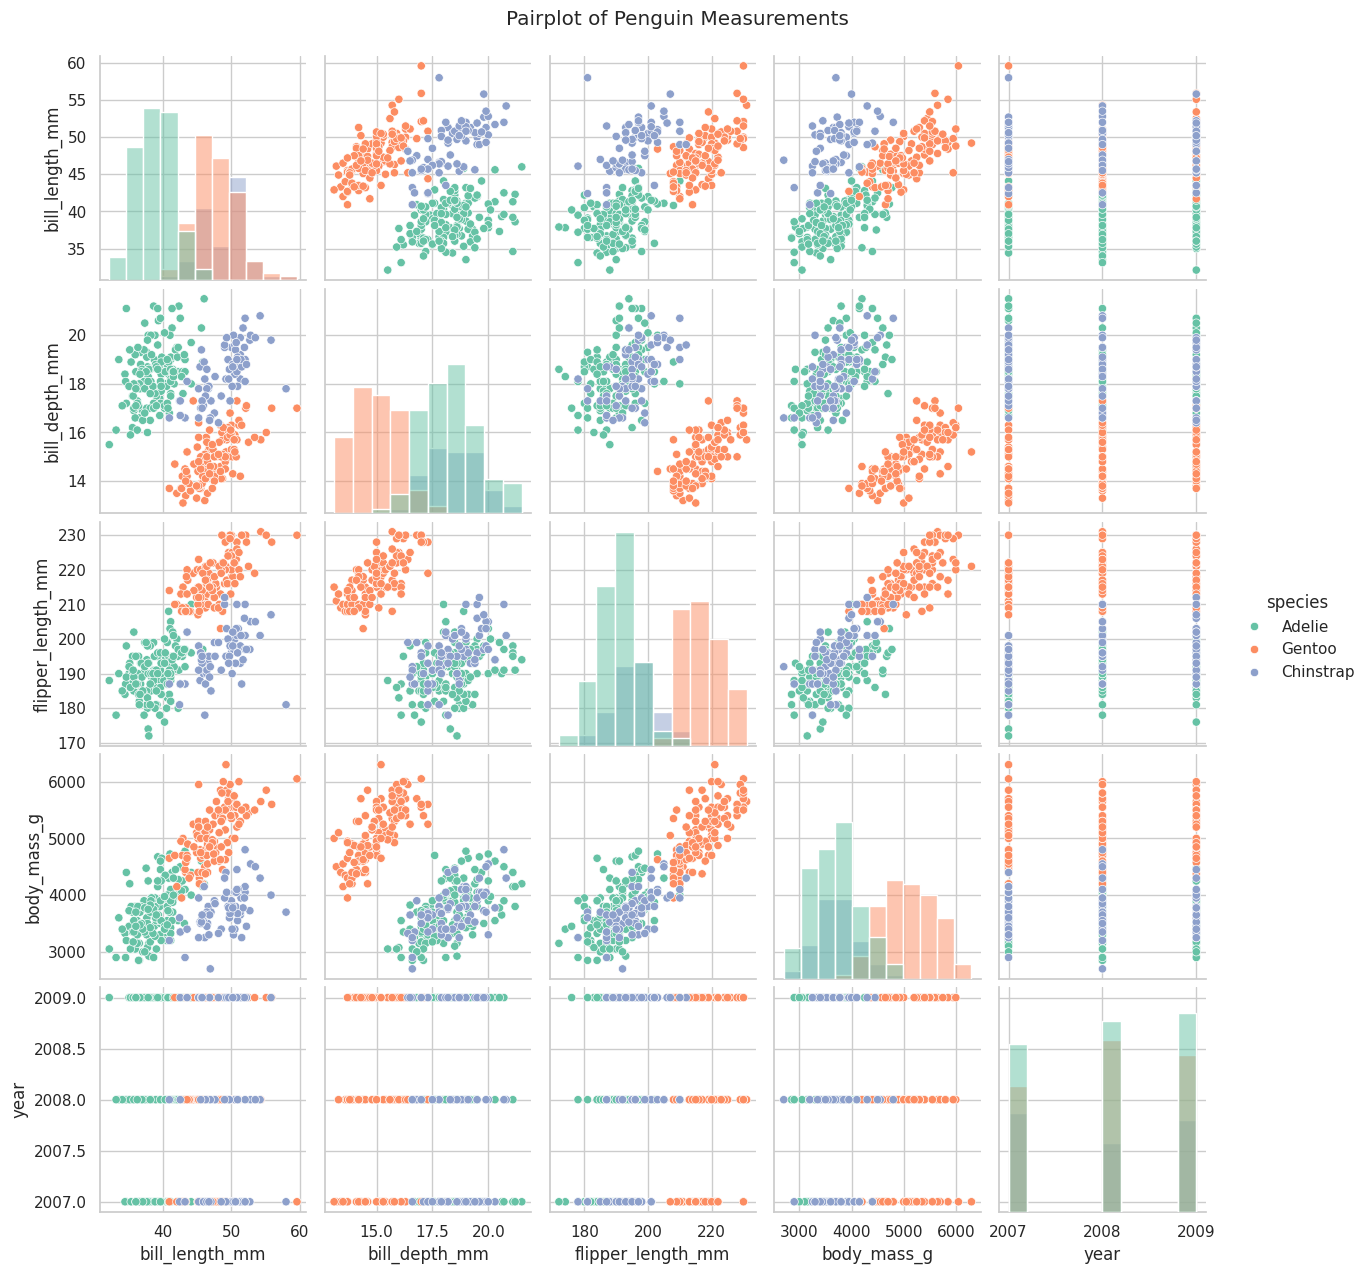

In [15]:
# Cell 12 — Pairplot of numerical features
sns.pairplot(df_clean, hue="species", diag_kind="hist", palette="Set2")
plt.suptitle("Pairplot of Penguin Measurements", y=1.02)
plt.show()


In [16]:
# Cell 13 — Conclusion
print("""
Conclusions & Insights:
- Adelie penguins dominate in count, but Gentoo are largest in body mass.
- Flipper length and body mass show a strong positive correlation across species.
- Bill length/depth clearly separate species clusters.
- Correlation heatmap confirms flipper length and body mass are strongly related.
- Sex distribution varies by species, some more balanced than others.
- Islands host different proportions of species, reflecting ecological niches.
""")



Conclusions & Insights:
- Adelie penguins dominate in count, but Gentoo are largest in body mass.
- Flipper length and body mass show a strong positive correlation across species.
- Bill length/depth clearly separate species clusters.
- Correlation heatmap confirms flipper length and body mass are strongly related.
- Sex distribution varies by species, some more balanced than others.
- Islands host different proportions of species, reflecting ecological niches.

